# Decell Chicken Constructs — Actuation Analysis 2026-04-15

Two experiments:
- **Baseline**: `pyrroleDBS-baselineactuation.csv` + `pyrrole-baseline.mov` — 120 s applied voltage intervals
- **Decell chicken 1 soak**: `decel-chicken-1soakactuation.csv` + `decell_chicken_1_soak.mov` — 200 s applied voltage intervals

Pipeline:
1. Extract Force Out (V) from video via EasyOCR on raw color crop
2. Load current CSV
3. Synthesize applied voltage trace (±0.8 V steps)
4. Synchronize + merge all signals
5. Convert Force Out voltage → force (mN)
6. Plot + export

In [37]:
import cv2
import numpy as np
import pandas as pd
import torch
import re
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from scipy.signal import medfilt

from train_display_cnn import DisplayCNN, pad_resize, BLANK, N_SLOTS

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
_ckpt = torch.load('display_cnn.pt', map_location=device, weights_only=True)
cnn = DisplayCNN().to(device).eval()
cnn.load_state_dict(_ckpt['model'])
print(f'Display CNN loaded on {device}')

Display CNN loaded on mps


In [38]:
# ── Experiment configuration ──────────────────────────────────────────────
DATA_DIR = Path('actuation_currents_data')

EXPERIMENTS = {
    'baseline': dict(
        video           = DATA_DIR / '2026.4.15-pyrrole-baseline.mov',
        current_csv     = DATA_DIR / '2026.04.15-pyrroleDBS-baselineactuation.csv',
        force_cnn_csv   = DATA_DIR / '2026.4.15-pyrrole-baseline_force_cnn.csv',
        merged_csv      = DATA_DIR / '2026.4.15-pyrrole-baseline_merged.csv',
        crop            = dict(y0=790, y1=884, x0=1175, x1=1415),
        n_digits        = 4,
        v_min           = 6.5,  v_max = 9.0,
        gain            = 5.0,
        interval_s      = 120,
        video_offset_s  = 0.0,
        color           = 'steelblue',
        thickness_mm    = 0.0395,
        width_mm        = 3.0,
        cross_section_note = None,
    ),
    'decell_1soak': dict(
        video           = DATA_DIR / '2026.4.15-decell_chicken_1_soak.mov',
        current_csv     = DATA_DIR / '2026.4.15-decel-chicken-1soakactuation.csv',
        force_cnn_csv   = DATA_DIR / '2026.4.15-decell_chicken_1_soak_force_cnn.csv',
        merged_csv      = DATA_DIR / '2026.4.15-decell_chicken_1_soak_merged.csv',
        crop            = dict(y0=812, y1=909, x0=1095, x1=1372),
        n_digits        = 5,
        v_min           = 9.0,  v_max = 14.0,
        gain            = 5.0,
        interval_s      = 200,
        video_offset_s  = 0.0,
        color           = 'seagreen',
        thickness_mm    = 0.2530,
        width_mm        = 3.0,
        cross_section_note = '*',  # uncertain measurement
    ),
    'decell_3soak': dict(
        video           = DATA_DIR / '2026.4.15-decell_chicken_3_soak.mov',
        current_csv     = DATA_DIR / '2026.4.15-decel-chicken-3soakactuation.csv',
        force_cnn_csv   = DATA_DIR / '2026.4.15-decell_chicken_3_soak_force_cnn.csv',
        merged_csv      = DATA_DIR / '2026.4.15-decell_chicken_3_soak_merged.csv',
        crop            = dict(y0=692, y1=782, x0=1120, x1=1392),
        n_digits        = 4,
        v_min           = 1.0,  v_max = 6.0,
        gain            = 1.0,
        interval_s      = 200,
        video_offset_s  = 0.0,
        color           = 'darkorange',
        thickness_mm    = None,
        width_mm        = None,
        cross_section_note = None,
    ),
    'decell_fresh': dict(
        video           = DATA_DIR / '2026.4.15-decell_chicken_fresh.mov',
        current_csv     = DATA_DIR / '2026.4.15-decel-chicken-fresh-actuation.csv',
        force_cnn_csv   = DATA_DIR / '2026.4.15-decell_chicken_fresh_force_cnn.csv',
        merged_csv      = DATA_DIR / '2026.4.15-decell_chicken_fresh_merged.csv',
        crop            = dict(y0=819, y1=907, x0=1010, x1=1285),
        n_digits        = 4,
        v_min           = 1.0,  v_max = 6.0,
        gain            = 1.0,
        interval_s      = 200,
        video_offset_s  = 0.0,
        color           = 'mediumpurple',
        thickness_mm    = None,
        width_mm        = None,
        cross_section_note = None,
    ),
    'decell_2soak': dict(
        video           = DATA_DIR / '2026.4.16-decel-2soakANDelectropolymeization.mov',
        current_csv     = DATA_DIR / '2026.4.16-decel-2soakANDelectropolymeization-actuation.csv',
        force_cnn_csv   = DATA_DIR / '2026.4.16-decell_chicken_2_soak_force_cnn.csv',
        merged_csv      = DATA_DIR / '2026.4.16-decell_chicken_2_soak_merged.csv',
        crop            = dict(y0=690, y1=790, x0=1175, x1=1450),
        n_digits        = 4,
        v_min           = 6.5,  v_max = 9.0,
        gain            = 5.0,
        interval_s      = 200,
        video_offset_s  = 0.0,
        color           = 'crimson',
        thickness_mm    = 0.7090,
        width_mm        = 4.0,
        cross_section_note = None,
    ),
    'decell_3soak_dry_rewet': dict(
        video           = DATA_DIR / '2026.4.16-decel-3soak-dry-then-rewet.mov',
        current_csv     = DATA_DIR / '2026.4.16-decel-3soak-dry-then-rewet-actuation.csv',
        force_cnn_csv   = DATA_DIR / '2026.4.16-decell_chicken_3_soak_dry_rewet_force_cnn.csv',
        merged_csv      = DATA_DIR / '2026.4.16-decell_chicken_3_soak_dry_rewet_merged.csv',
        crop            = dict(y0=731, y1=825, x0=1114, x1=1354),
        n_digits        = 4,
        v_min           = 9.4,  v_max = 11.0,
        gain            = 5.0,
        interval_s      = 200,
        video_offset_s  = 0.0,
        color           = 'teal',
        thickness_mm    = 0.5445,
        width_mm        = 1.5,
        cross_section_note = None,
    ),
}

# ── Force calibration ──────────────────────────────────────────────────────
# Measured: 11.39 mN/V at 5× gain on the Aurora Scientific lever.
# force_V is gain-normalized (raw / experiment_gain), so to convert:
#   force_mN = force_V × 11.39 × 5 = force_V × CAL_mN_per_V
CAL_mN_per_V_AT_REF = 11.39
CAL_REF_GAIN        = 5
CAL_mN_per_V        = CAL_mN_per_V_AT_REF * CAL_REF_GAIN  # 569.5 mN / V_sensor

# ── Applied voltage protocol ───────────────────────────────────────────────
APPLIED_V_AMPLITUDE = 0.8

# ── Sampling + smoothing ───────────────────────────────────────────────────
OCR_DT_S      = 0.5
MEDIAN_WINDOW = 21

print(f'{len(EXPERIMENTS)} experiments configured')
print(f'{"tag":22s}  {"gain":>5s}  {"nd":>3s}  {"range":>13s}  {"interval":>8s}  {"cross-section":>18s}')
print('-' * 80)
for tag, cfg in EXPERIMENTS.items():
    t, w = cfg.get('thickness_mm'), cfg.get('width_mm')
    note = cfg.get('cross_section_note', '') or ''
    if t and w:
        xs = f'{t:.4f}×{w:.1f} mm²{note}'
    else:
        xs = '—'
    print(f'{tag:22s}  {cfg["gain"]:4.0f}×  {cfg["n_digits"]:3d}  '
          f'[{cfg["v_min"]},{cfg["v_max"]}]{"":<5s}  {cfg["interval_s"]:5d} s  {xs:>18s}')
print(f'\nMedian filter: window={MEDIAN_WINDOW} ({MEDIAN_WINDOW*OCR_DT_S:.1f} s)')

6 experiments configured
tag                      gain   nd          range  interval       cross-section
--------------------------------------------------------------------------------
baseline                   5×    4  [6.5,9.0]         120 s      0.0395×3.0 mm²
decell_1soak               5×    5  [9.0,14.0]         200 s     0.2530×3.0 mm²*
decell_3soak               1×    4  [1.0,6.0]         200 s                   —
decell_fresh               1×    4  [1.0,6.0]         200 s                   —
decell_2soak               5×    4  [6.5,9.0]         200 s      0.7090×4.0 mm²
decell_3soak_dry_rewet     5×    4  [9.4,11.0]         200 s      0.5445×1.5 mm²

Median filter: window=21 (10.5 s)


## Step 1 — Extract Force Out (V) from video using the fine-tuned CNN

Each video frame's display crop is fed to the CNN, which outputs 5 digit slots
(blank + 0–9). Digits are concatenated and the decimal inserted 3 from the right.
Readings outside the plausible range are set to NaN and linearly interpolated.

In [39]:
@torch.no_grad()
def predict_display_batch(crops_bgr):
    if not crops_bgr:
        return []
    imgs = np.stack([pad_resize(cv2.cvtColor(c, cv2.COLOR_BGR2RGB))
                     for c in crops_bgr])
    x = torch.from_numpy(imgs).permute(0, 3, 1, 2).float().to(device) / 255.0
    return cnn(x).argmax(-1).cpu().numpy()  # (B, 5)


def slots_to_voltage(slots, n_digits, v_min, v_max):
    """CNN slot predictions → raw display voltage (or None if invalid)."""
    lead = slots[:N_SLOTS - n_digits]
    digs = slots[N_SLOTS - n_digits:]
    if any(d == BLANK for d in digs) or any(d != BLANK for d in lead):
        return None
    s = ''.join(str(int(d)) for d in digs)
    v = float(f'{int(s[:-3] or 0)}.{s[-3:]}')
    return v if v_min <= v <= v_max else None


def extract_force_voltage(tag, cfg, dt=OCR_DT_S, batch_size=32,
                          median_window=MEDIAN_WINDOW):
    """Run CNN on the Force Out display for one experiment.

    Returns a DataFrame with columns:
        time_s     — video time (seconds)
        force_V    — gain-normalized voltage (raw / gain)  ← use for mN conversion
        force_V_raw — raw display reading
    """
    out_csv = cfg['force_cnn_csv']
    if out_csv.exists():
        print(f'[{tag}] {out_csv.name} exists — loading cache. Delete to re-run.')
        return pd.read_csv(out_csv)

    cap = cv2.VideoCapture(str(cfg['video']))
    fps = cap.get(cv2.CAP_PROP_FPS)
    dur = cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps
    print(f'[{tag}] {cfg["video"].name}: {dur:.0f} s  |  {fps:.1f} fps')

    timestamps = np.arange(0, dur, dt)
    records = []
    buf_crops, buf_times = [], []

    def flush():
        if not buf_crops:
            return
        preds = predict_display_batch(buf_crops)
        for t, slots in zip(buf_times, preds):
            v = slots_to_voltage(slots, cfg['n_digits'], cfg['v_min'], cfg['v_max'])
            records.append({'time_s': round(t, 3), 'force_V_raw': v})
        buf_crops.clear(); buf_times.clear()

    c = cfg['crop']
    for t in tqdm(timestamps, desc=tag):
        cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000)
        ret, frame = cap.read()
        if not ret:
            records.append({'time_s': round(t, 3), 'force_V_raw': np.nan})
            continue
        buf_crops.append(frame[c['y0']:c['y1'], c['x0']:c['x1']])
        buf_times.append(t)
        if len(buf_crops) >= batch_size:
            flush()
    flush()
    cap.release()

    df = pd.DataFrame(records).sort_values('time_s').reset_index(drop=True)
    n_ok  = df['force_V_raw'].notna().sum()
    n_bad = df['force_V_raw'].isna().sum()
    print(f'  CNN: {n_ok} ok  |  {n_bad} rejected ({100*n_bad/len(df):.1f}% NaN)')
    df['force_V_raw'] = df['force_V_raw'].interpolate(method='linear', limit_direction='both')

    # Gain normalization + median smoothing
    df['force_V'] = df['force_V_raw'] / cfg['gain']
    if median_window and median_window >= 3:
        df['force_V'] = medfilt(df['force_V'].values, kernel_size=median_window)

    df.to_csv(out_csv, index=False)
    print(f'  Saved → {out_csv.name}')
    return df

In [40]:
# Run CNN on every experiment video. Cached CSVs are reused — delete the
# force_cnn.csv files to re-run.
force_dfs = {tag: extract_force_voltage(tag, cfg) for tag, cfg in EXPERIMENTS.items()}

for tag, df in force_dfs.items():
    print(f'[{tag}] {len(df):>5d} rows  |  raw {df["force_V_raw"].min():.3f}–{df["force_V_raw"].max():.3f} V'
          f'   normalized {df["force_V"].min():.3f}–{df["force_V"].max():.3f} V')

[baseline] 2026.4.15-pyrrole-baseline_force_cnn.csv exists — loading cache. Delete to re-run.
[decell_1soak] 2026.4.15-decell_chicken_1_soak_force_cnn.csv exists — loading cache. Delete to re-run.
[decell_3soak] 2026.4.15-decell_chicken_3_soak_force_cnn.csv exists — loading cache. Delete to re-run.
[decell_fresh] 2026.4.15-decell_chicken_fresh_force_cnn.csv exists — loading cache. Delete to re-run.
[decell_2soak] 2026.4.16-decell_chicken_2_soak_force_cnn.csv exists — loading cache. Delete to re-run.
[decell_3soak_dry_rewet] 2026.4.16-decell_chicken_3_soak_dry_rewet_force_cnn.csv exists — loading cache. Delete to re-run.
[baseline]  2000 rows  |  raw 6.665–7.688 V   normalized 1.333–1.529 V
[decell_1soak]  3237 rows  |  raw 11.612–11.820 V   normalized 2.323–2.363 V
[decell_3soak]  3124 rows  |  raw 1.777–5.955 V   normalized 1.777–3.866 V
[decell_fresh]  3046 rows  |  raw 3.145–5.666 V   normalized 3.145–3.194 V
[decell_2soak]  4029 rows  |  raw 6.555–8.107 V   normalized 1.311–1.621 V

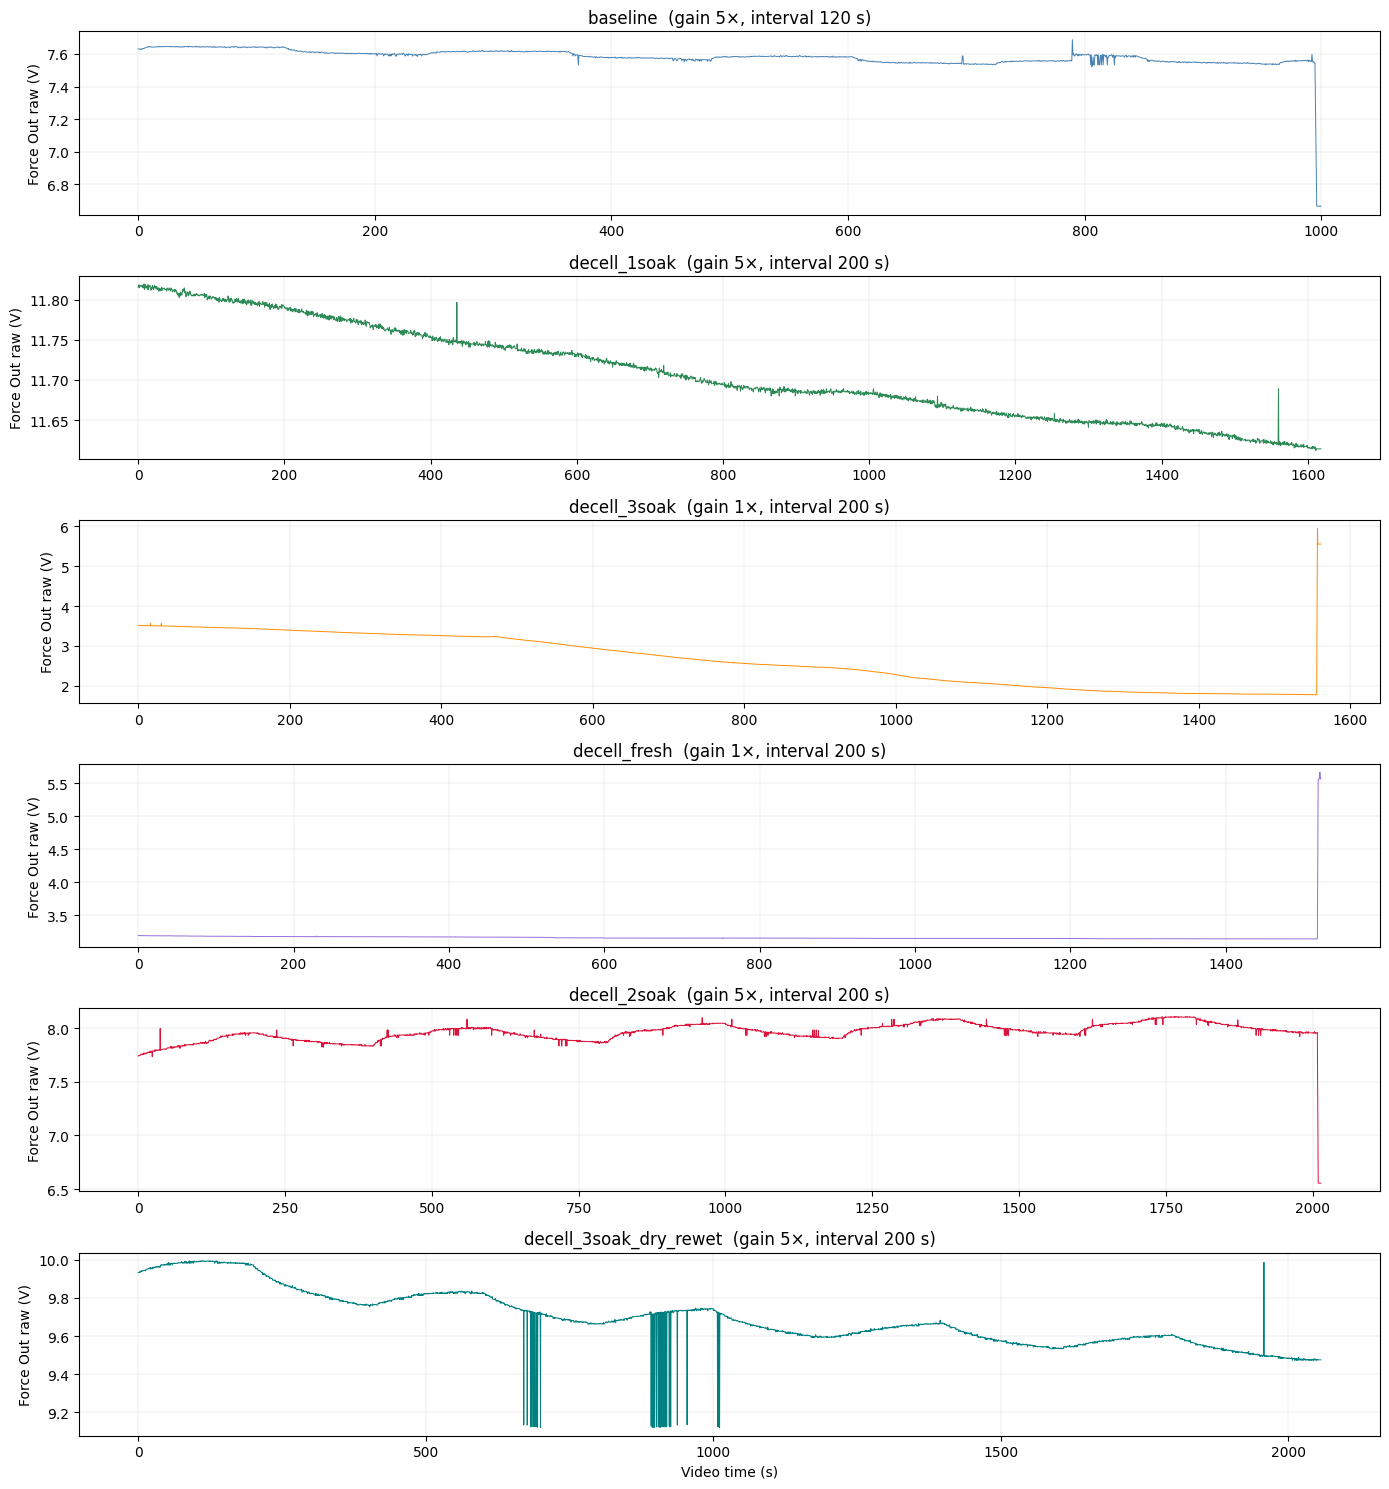

In [41]:
# Sanity plot — raw (pre-gain) readings for each experiment
fig, axes = plt.subplots(len(EXPERIMENTS), 1, figsize=(14, 2.5 * len(EXPERIMENTS)),
                         sharex=False)
if len(EXPERIMENTS) == 1: axes = [axes]
for ax, (tag, cfg) in zip(axes, EXPERIMENTS.items()):
    df = force_dfs[tag]
    ax.plot(df['time_s'], df['force_V_raw'], lw=0.7, color=cfg['color'])
    ax.set(ylabel='Force Out raw (V)',
           title=f'{tag}  (gain {cfg["gain"]:.0f}×, interval {cfg["interval_s"]} s)')
    ax.grid(True, lw=0.3, alpha=0.5)
axes[-1].set_xlabel('Video time (s)')
plt.tight_layout(); plt.show()

## Step 2 — Load current CSVs

In [42]:
def load_current_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding='utf-16', skiprows=5)
    df.columns = ['time_s', 'current_uA']
    df['time_s']     = pd.to_numeric(df['time_s'],     errors='coerce')
    df['current_uA'] = pd.to_numeric(df['current_uA'], errors='coerce')
    df = df.dropna().reset_index(drop=True)
    print(f'{path.name}: {len(df)} rows, t = {df.time_s.min():.1f} – {df.time_s.max():.1f} s')
    return df


current_dfs = {tag: load_current_csv(cfg['current_csv'])
               for tag, cfg in EXPERIMENTS.items()}

2026.04.15-pyrroleDBS-baselineactuation.csv: 9854 rows, t = 0.0 – 985.3 s
2026.4.15-decel-chicken-1soakactuation.csv: 16094 rows, t = 0.0 – 1609.3 s
2026.4.15-decel-chicken-3soakactuation.csv: 15635 rows, t = 0.0 – 1563.4 s
2026.4.15-decel-chicken-fresh-actuation.csv: 15156 rows, t = 0.0 – 1515.5 s
2026.4.16-decel-2soakANDelectropolymeization-actuation.csv: 20001 rows, t = 0.0 – 2000.0 s
2026.4.16-decel-3soak-dry-then-rewet-actuation.csv: 20001 rows, t = 0.0 – 2000.0 s


## Step 3 — Synthesize applied voltage trace

Applied voltage steps ±0.8 V at fixed intervals:  
- **Baseline**: 120 s half-cycle → +0.8 V for 0–120 s, −0.8 V for 120–240 s, …  
- **Decell**: 200 s half-cycle

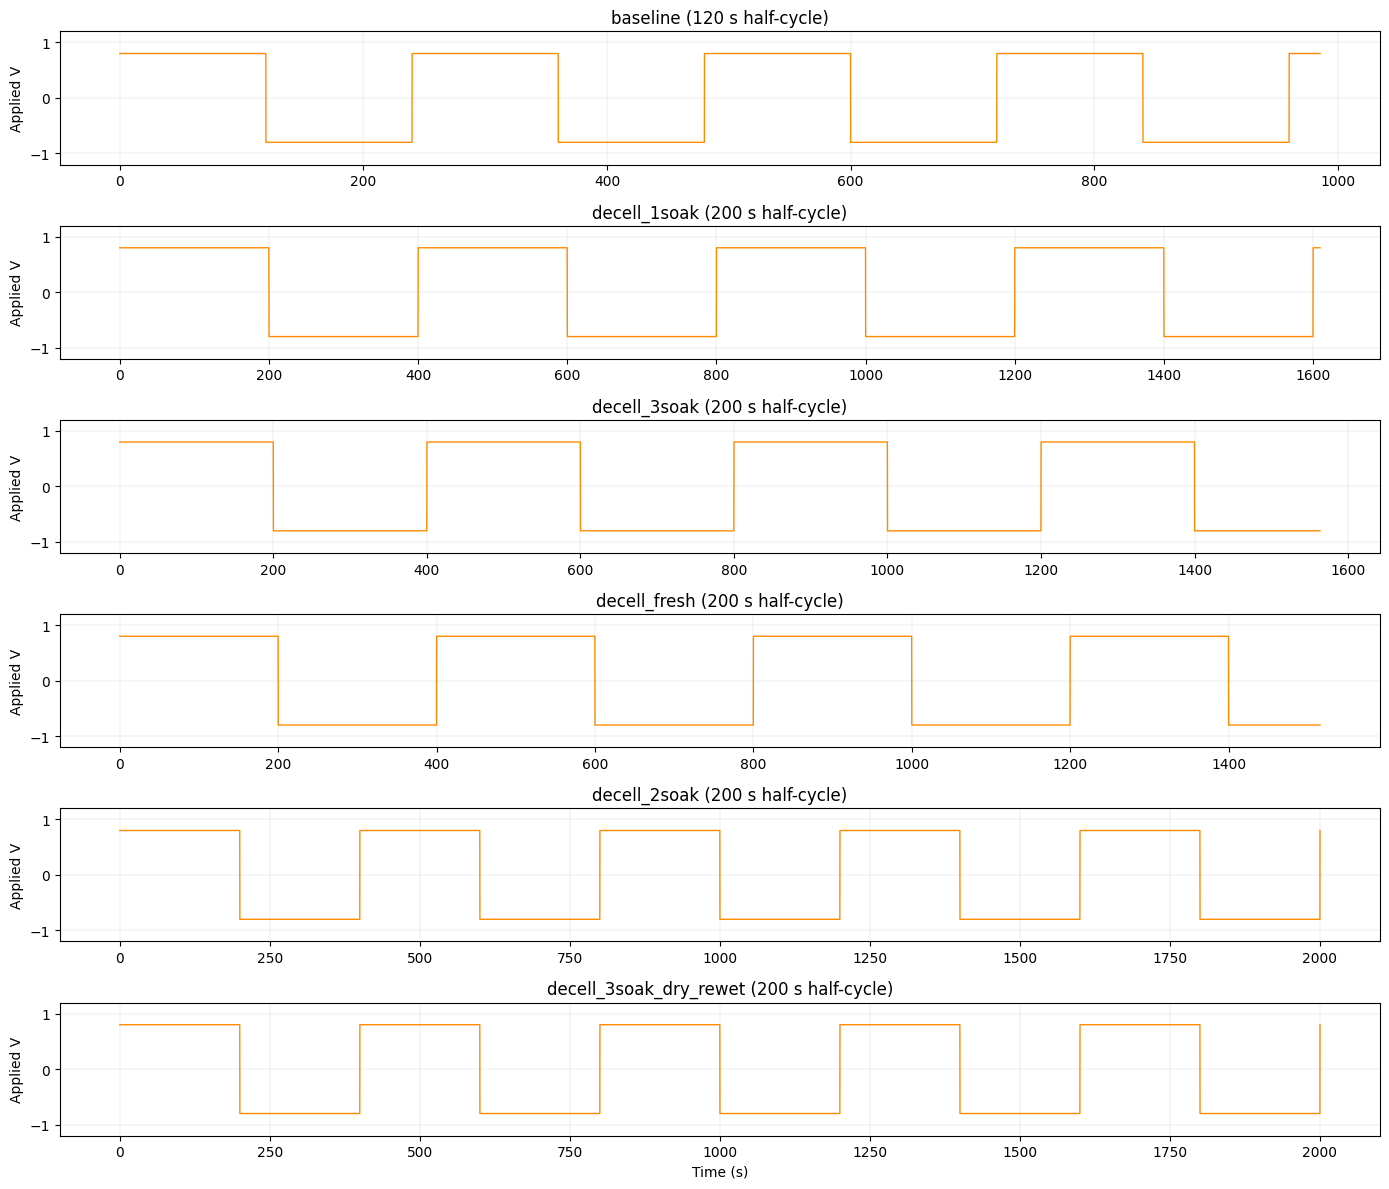

In [43]:
def make_applied_voltage(time_s, interval_s, amplitude=APPLIED_V_AMPLITUDE):
    """Step function: +amplitude for first half-cycle, -amplitude for second, etc."""
    cycle = (time_s // interval_s).astype(int)
    return np.where(cycle % 2 == 0, +amplitude, -amplitude)


for tag, cfg in EXPERIMENTS.items():
    current_dfs[tag]['applied_V'] = make_applied_voltage(
        current_dfs[tag]['time_s'].values, cfg['interval_s'])

# Quick visual check
fig, axes = plt.subplots(len(EXPERIMENTS), 1, figsize=(14, 2.0 * len(EXPERIMENTS)))
if len(EXPERIMENTS) == 1: axes = [axes]
for ax, (tag, cfg) in zip(axes, EXPERIMENTS.items()):
    df = current_dfs[tag]
    ax.plot(df['time_s'], df['applied_V'], lw=1.0, color='darkorange')
    ax.set(ylabel='Applied V', title=f'{tag} ({cfg["interval_s"]} s half-cycle)',
           ylim=(-1.2, 1.2))
    ax.grid(True, lw=0.3, alpha=0.5)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

## Step 4 — Synchronize and merge

Adjust `BASELINE_VIDEO_OFFSET_S` / `DECELL_VIDEO_OFFSET_S` until the force signal
step edges align with the applied voltage transitions in the combined plot below.

In [44]:
def merge_signals(df_current, df_force, video_offset_s):
    df_f = df_force.copy()
    df_f['time_s'] = df_f['time_s'] + video_offset_s
    df_f = df_f.sort_values('time_s')
    merged = pd.merge_asof(
        df_current.sort_values('time_s'),
        df_f.rename(columns={'time_s': 'time_s_video'}),
        left_on='time_s', right_on='time_s_video',
        direction='nearest', tolerance=1.0,
    ).drop(columns=['time_s_video'], errors='ignore')
    return merged


merged_dfs = {}
for tag, cfg in EXPERIMENTS.items():
    merged = merge_signals(current_dfs[tag], force_dfs[tag], cfg['video_offset_s'])
    n = merged['force_V'].notna().sum()
    print(f'[{tag}] merged {n}/{len(merged)} rows have force_V')
    merged_dfs[tag] = merged

[baseline] merged 9854/9854 rows have force_V
[decell_1soak] merged 16094/16094 rows have force_V
[decell_3soak] merged 15626/15635 rows have force_V
[decell_fresh] merged 15156/15156 rows have force_V
[decell_2soak] merged 20001/20001 rows have force_V
[decell_3soak_dry_rewet] merged 20001/20001 rows have force_V


## Step 5 — Force calibration

```
force_mN = (force_V - FORCE_OFFSET_V) × FORCE_SCALE_mN_per_V
```

Set `FORCE_OFFSET_V` to the resting Force Out voltage when no external force is applied  
(e.g. the baseline mean).  
Set `FORCE_SCALE_mN_per_V` from your Aurora Scientific calibration sheet.

In [45]:
for tag, cfg in EXPERIMENTS.items():
    df = merged_dfs[tag]
    df['force_mN'] = df['force_V'] * CAL_mN_per_V
    t_mm = cfg.get('thickness_mm')
    w_mm = cfg.get('width_mm')
    if t_mm and w_mm:
        area_mm2 = t_mm * w_mm
        df['stress_MPa'] = (df['force_mN'] * 1e-3) / area_mm2
        note = cfg.get('cross_section_note') or ''
        print(f'[{tag}] {t_mm:.4f}x{w_mm:.1f} mm2 = {area_mm2:.4f} mm2{note}  '
              f'force {df["force_mN"].min():.1f}-{df["force_mN"].max():.1f} mN  '
              f'stress {df["stress_MPa"].min():.3f}-{df["stress_MPa"].max():.3f} MPa')
    else:
        df['stress_MPa'] = np.nan
        print(f'[{tag}] force {df["force_mN"].min():.1f}-{df["force_mN"].max():.1f} mN  (no cross-section)')

print(f'Calibration: {CAL_mN_per_V_AT_REF} mN/V @ {CAL_REF_GAIN}x gain = {CAL_mN_per_V} mN/V_sensor')

[baseline] 0.0395x3.0 mm2 = 0.1185 mm2  force 85.8-87.1 mN  stress 0.724-0.735 MPa
[decell_1soak] 0.2530x3.0 mm2 = 0.7590 mm2*  force 132.3-134.6 mN  stress 0.174-0.177 MPa
[decell_3soak] force 101.2-220.2 mN  (no cross-section)
[decell_fresh] force 179.1-181.9 mN  (no cross-section)
[decell_2soak] 0.7090x4.0 mm2 = 2.8360 mm2  force 88.1-92.3 mN  stress 0.031-0.033 MPa
[decell_3soak_dry_rewet] 0.5445x1.5 mm2 = 0.8167 mm2  force 103.9-113.8 mN  stress 0.127-0.139 MPa
Calibration: 11.39 mN/V @ 5x gain = 56.95 mN/V_sensor


## Step 6 — Final plots

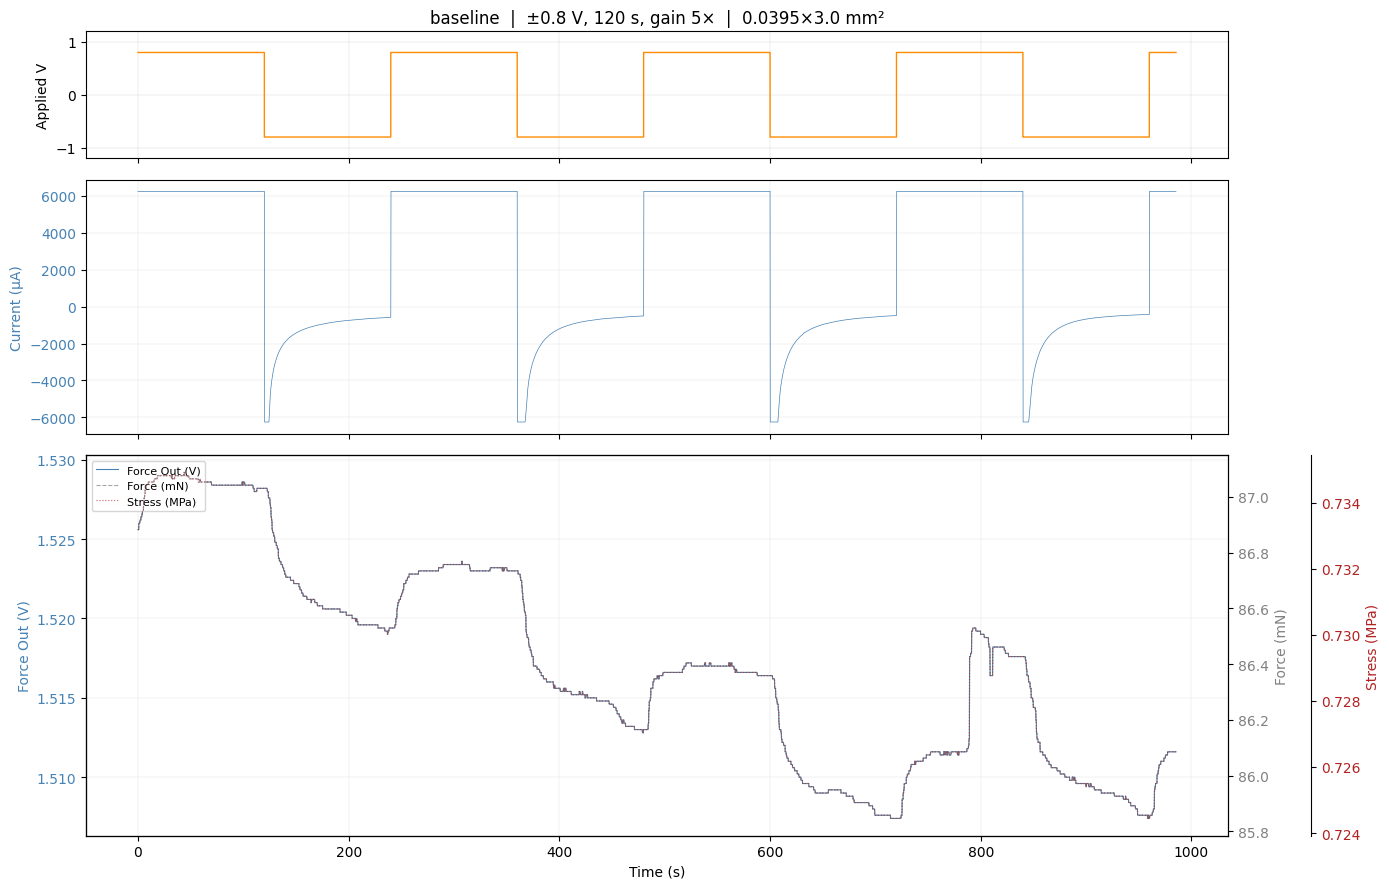

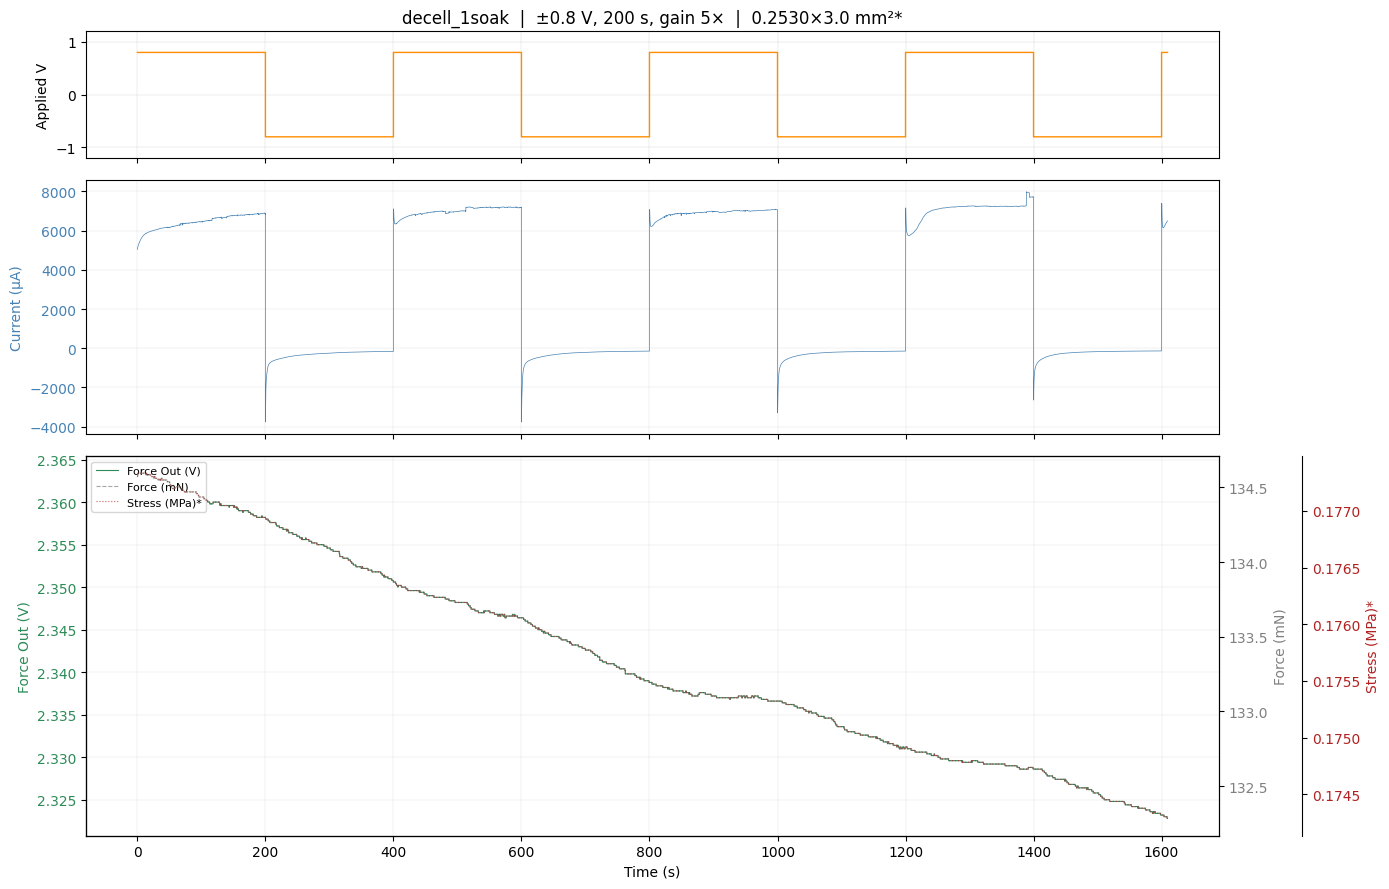

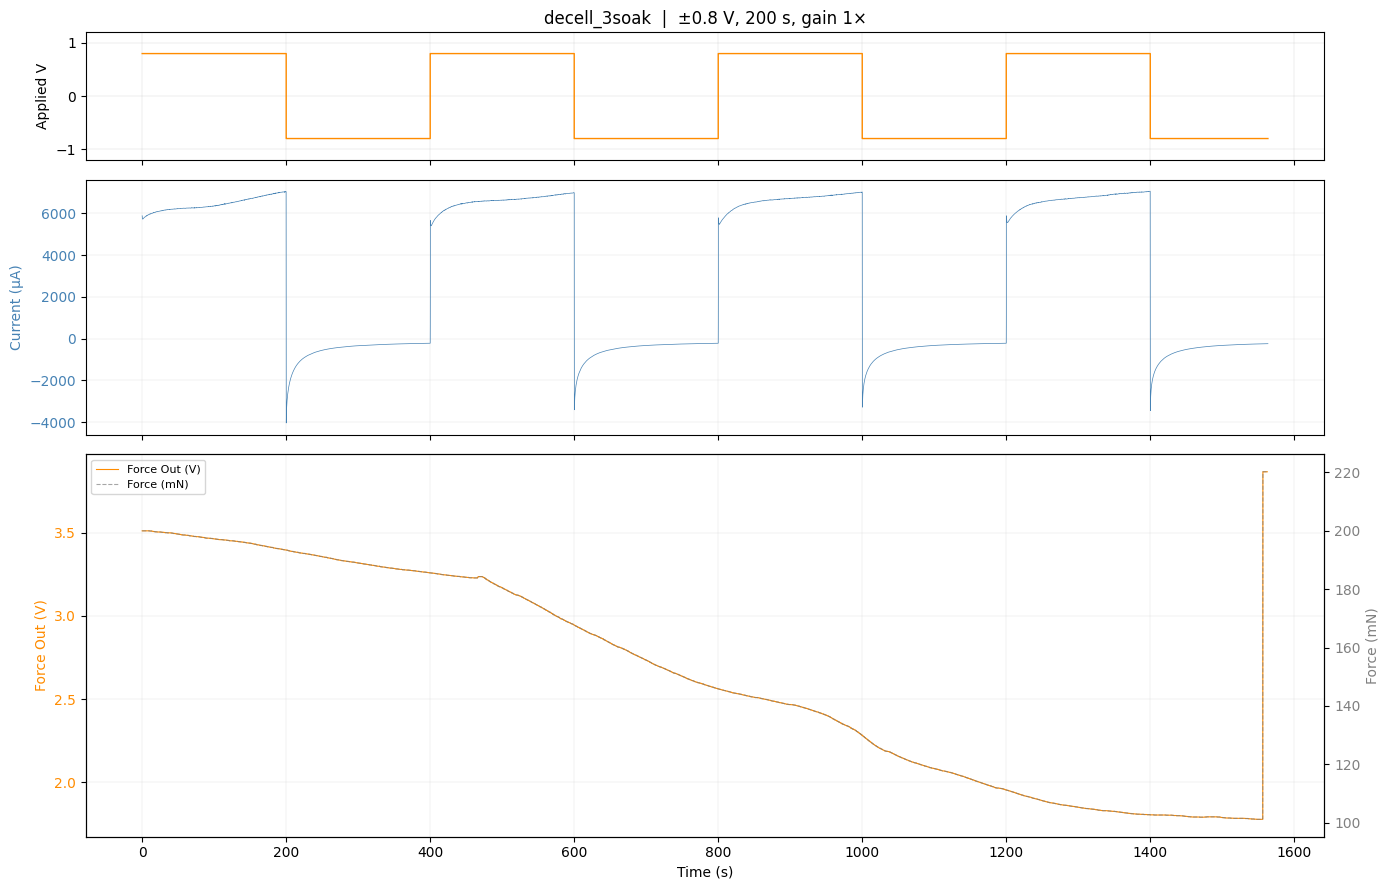

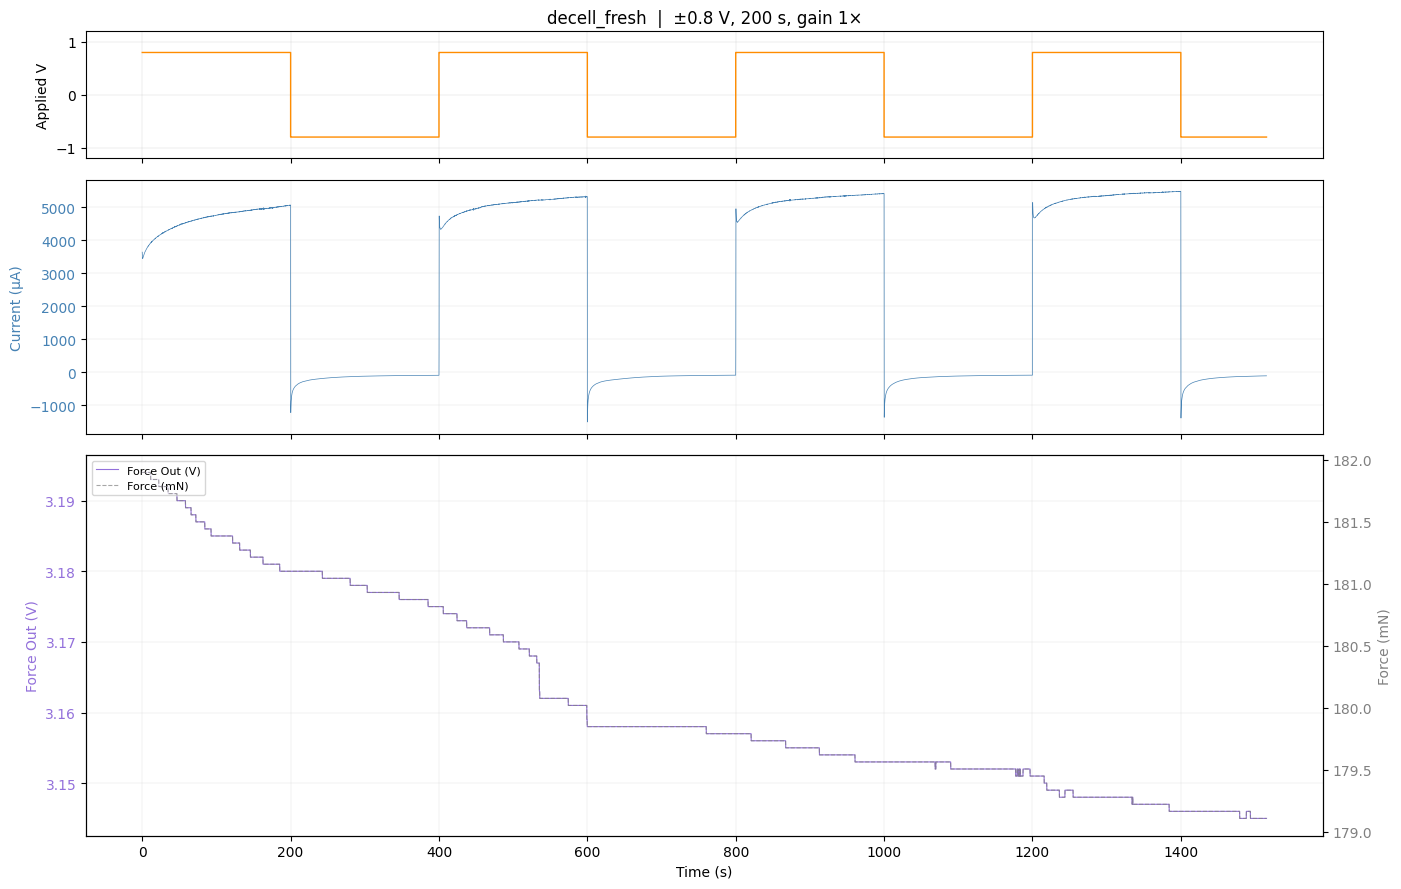

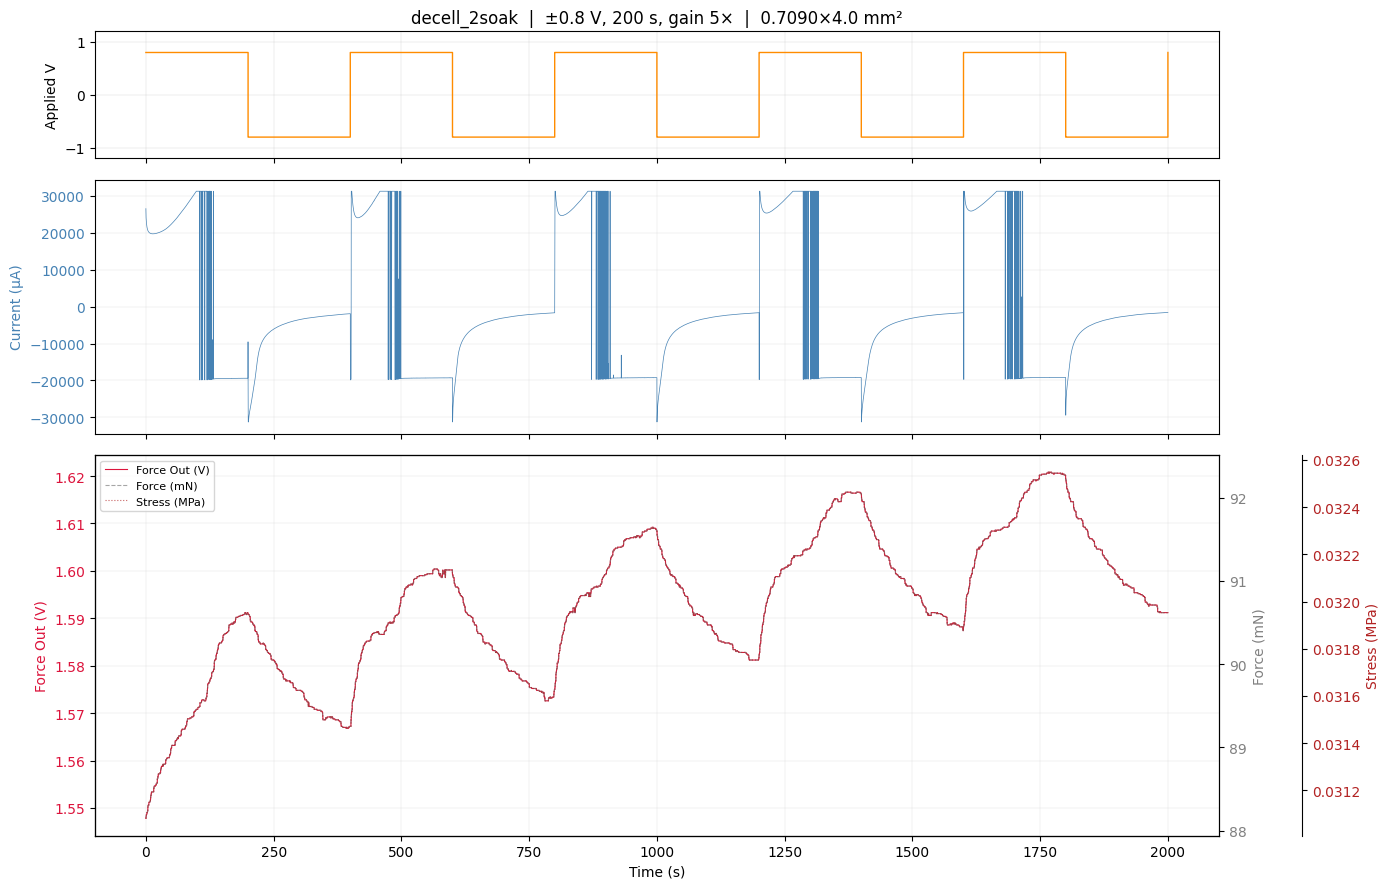

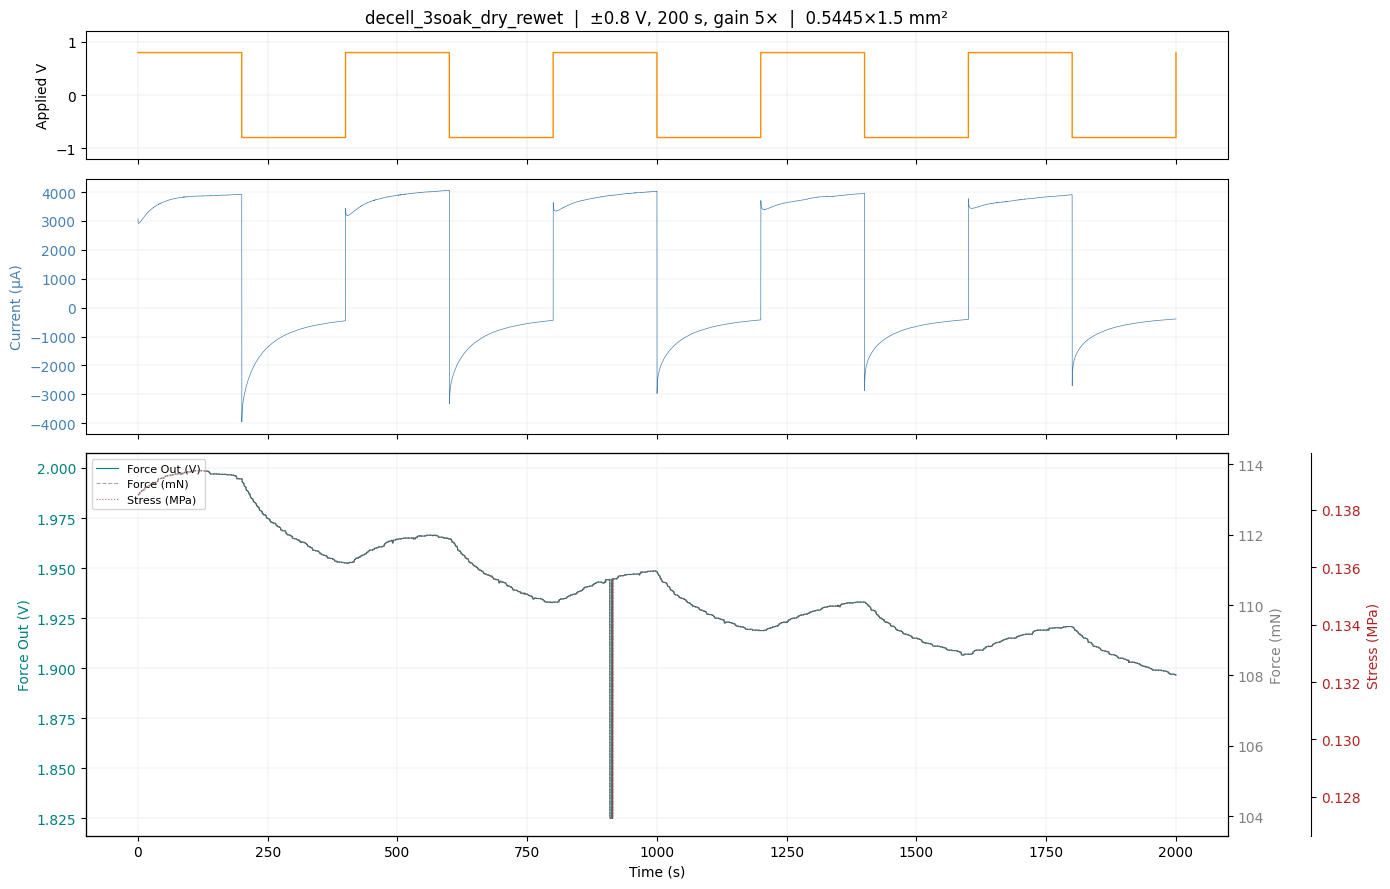

In [46]:
def plot_experiment(tag, df, cfg):
    has_stress = df['stress_MPa'].notna().any()
    note = cfg.get('cross_section_note') or ''
    t_mm = cfg.get('thickness_mm')
    w_mm = cfg.get('width_mm')
    title = f'{tag}  |  ±{APPLIED_V_AMPLITUDE} V, {cfg["interval_s"]} s, gain {cfg["gain"]:.0f}×'
    if t_mm and w_mm:
        title += f'  |  {t_mm:.4f}×{w_mm:.1f} mm²{note}'

    fig, (ax_top, ax_cur, ax_bot) = plt.subplots(3, 1, figsize=(14, 9),
                                          gridspec_kw={'height_ratios': [1, 2, 3]}, sharex=True)
    # Applied voltage
    ax_top.step(df['time_s'], df['applied_V'], lw=1.0, color='darkorange', where='post')
    ax_top.set(ylabel='Applied V', ylim=(-1.2, 1.2), title=title)
    ax_top.grid(True, lw=0.3, alpha=0.5)

    # Current
    ax_cur.plot(df['time_s'], df['current_uA'], lw=0.5, color='steelblue')
    ax_cur.set_ylabel('Current (µA)', color='steelblue')
    ax_cur.tick_params(axis='y', labelcolor='steelblue')
    ax_cur.grid(True, lw=0.3, alpha=0.4)

    # Force: V + mN + MPa on shared panel
    ln1 = ax_bot.plot(df['time_s'], df['force_V'], lw=0.8, color=cfg['color'],
                      label='Force Out (V)')
    ax_bot.set_ylabel('Force Out (V)', color=cfg['color'])
    ax_bot.tick_params(axis='y', labelcolor=cfg['color'])
    ax_bot.set_xlabel('Time (s)')
    ax_bot.grid(True, lw=0.3, alpha=0.4)

    ax_mN = ax_bot.twinx()
    ln2 = ax_mN.plot(df['time_s'], df['force_mN'], lw=0.8, color='gray',
                     alpha=0.7, ls='--', label='Force (mN)')
    ax_mN.set_ylabel('Force (mN)', color='gray')
    ax_mN.tick_params(axis='y', labelcolor='gray')

    lines = ln1 + ln2
    if has_stress:
        ax_MPa = ax_bot.twinx()
        ax_MPa.spines['right'].set_position(('outward', 60))
        ln3 = ax_MPa.plot(df['time_s'], df['stress_MPa'], lw=0.8, color='firebrick',
                          alpha=0.7, ls=':', label=f'Stress (MPa){note}')
        ax_MPa.set_ylabel(f'Stress (MPa){note}', color='firebrick')
        ax_MPa.tick_params(axis='y', labelcolor='firebrick')
        lines += ln3

    ax_bot.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=8)
    plt.tight_layout(); plt.show()


for tag, cfg in EXPERIMENTS.items():
    plot_experiment(tag, merged_dfs[tag], cfg)


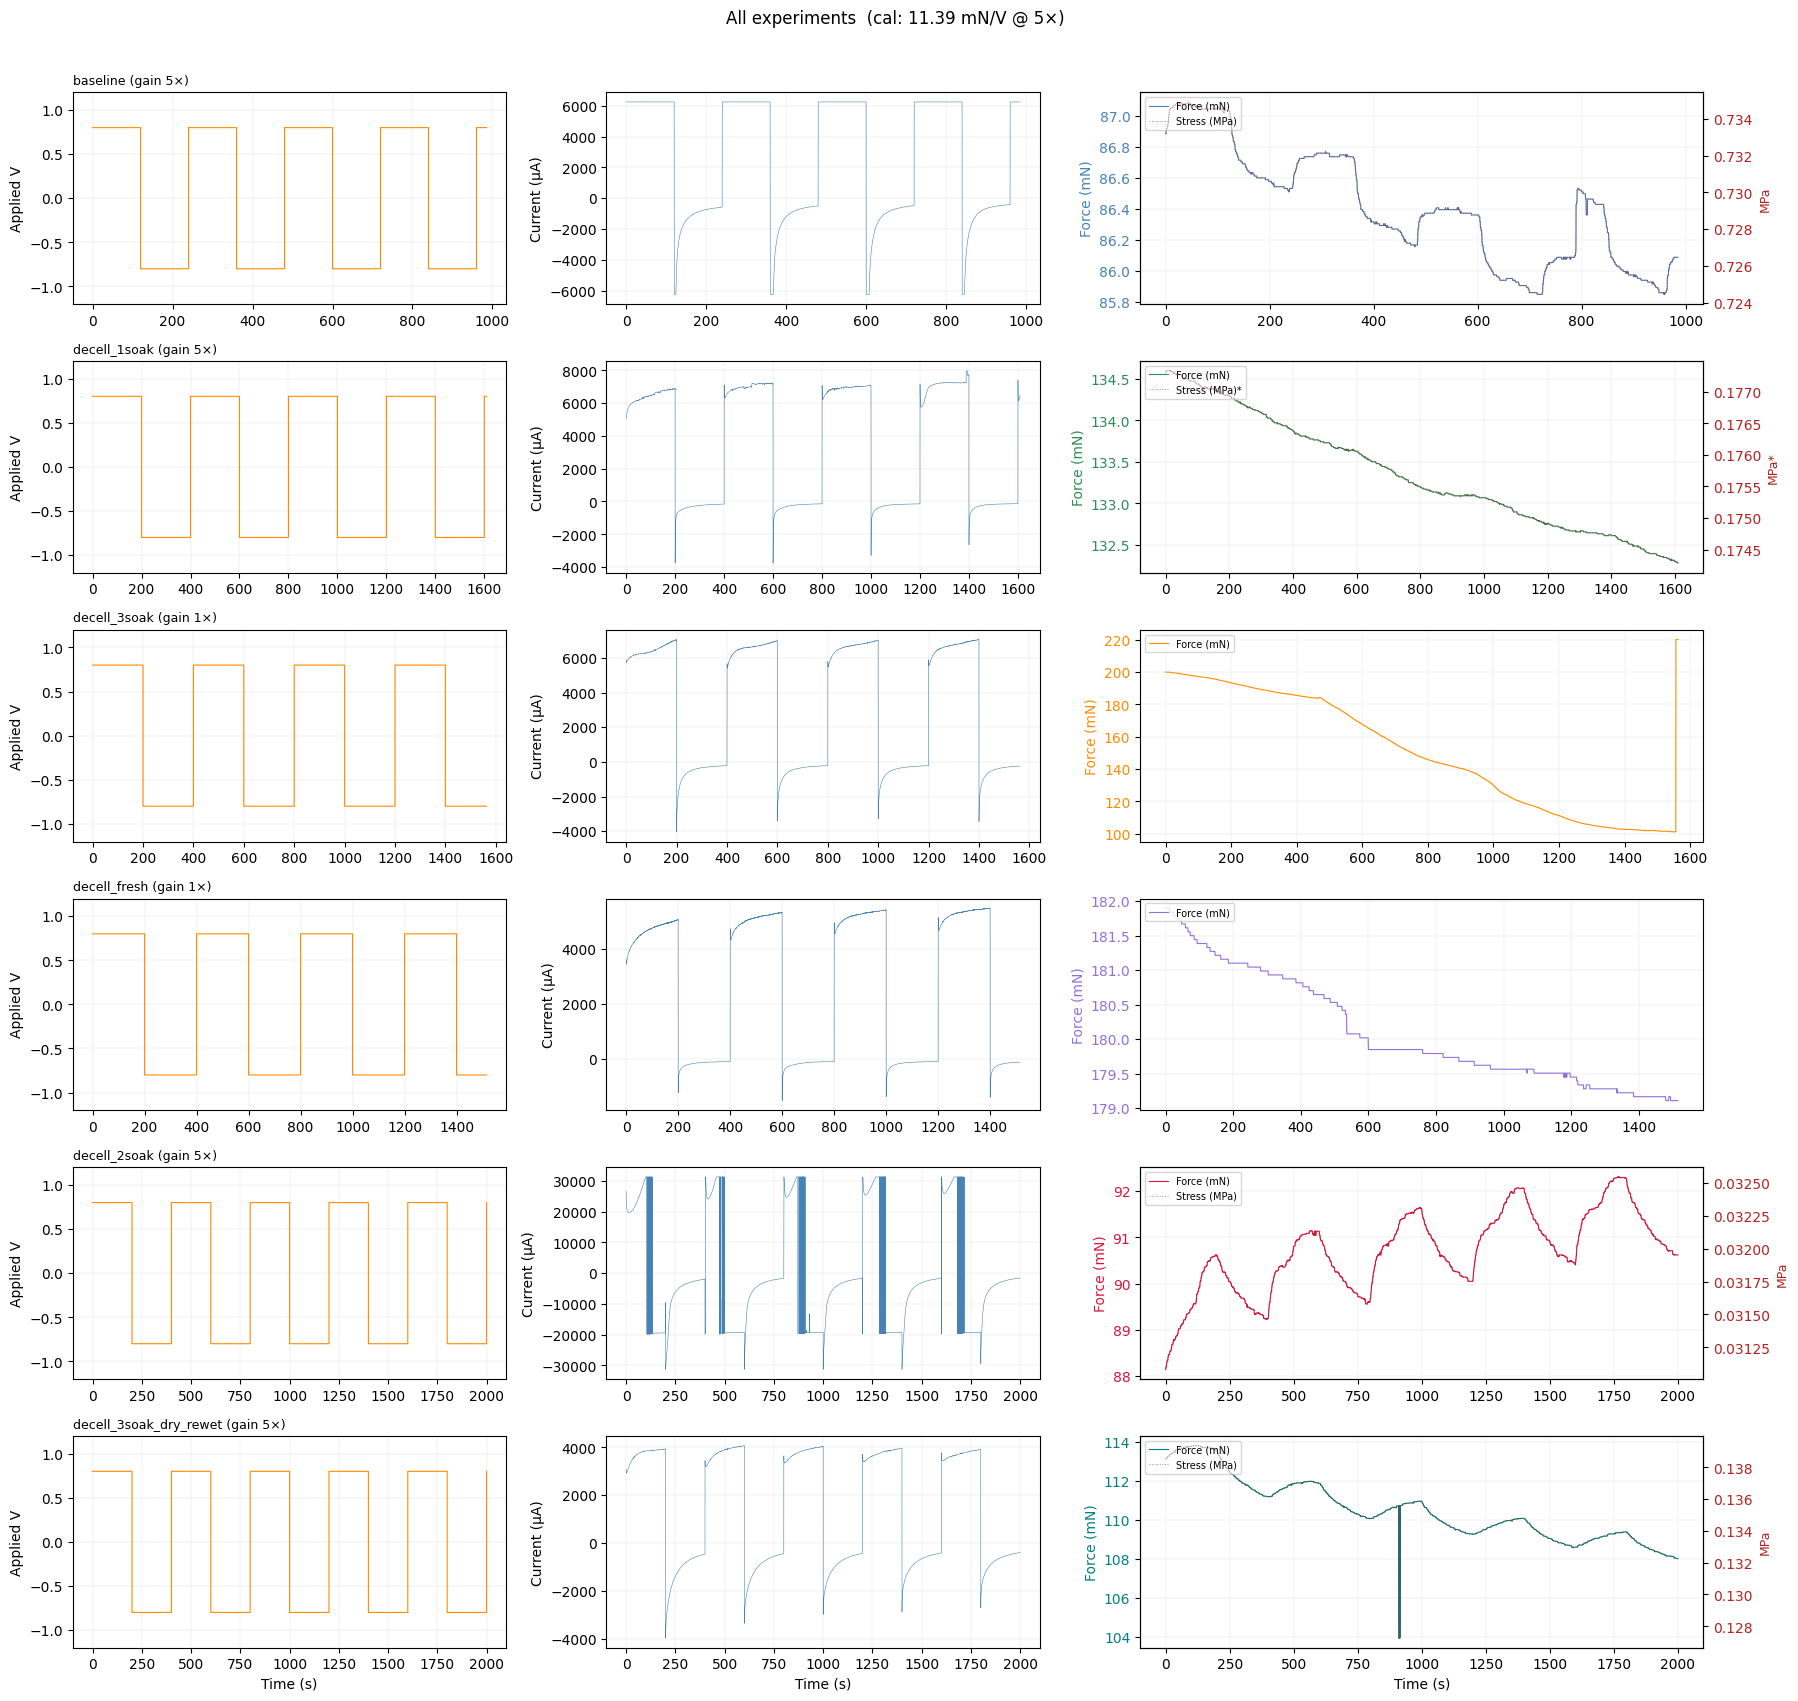


tag                         area mm²    F_min mN    F_max mN   σ_min MPa   σ_max MPa
------------------------------------------------------------------------------------------
baseline                      0.1185       85.85       87.09      0.7244      0.7349
decell_1soak*                 0.7590      132.28      134.60      0.1743      0.1773
decell_2soak                  2.8360       88.15       92.30      0.0311      0.0325
decell_3soak_dry_rewet        0.8167      103.93      113.82      0.1273      0.1394


In [47]:
# All experiments: applied V, current, and force/stress
n_exp = len(EXPERIMENTS)
fig, axes_all = plt.subplots(n_exp, 3, figsize=(18, 2.8 * n_exp),
                              gridspec_kw={'width_ratios': [1, 1, 1.3]})
if n_exp == 1: axes_all = axes_all[np.newaxis, :]

for row, (tag, cfg) in enumerate(EXPERIMENTS.items()):
    df = merged_dfs[tag]
    has_stress = df['stress_MPa'].notna().any()
    note = cfg.get('cross_section_note') or ''

    # Col 0: applied voltage
    ax = axes_all[row, 0]
    ax.step(df['time_s'], df['applied_V'], lw=0.8, color='darkorange', where='post')
    ax.set(ylabel='Applied V', ylim=(-1.2, 1.2))
    ax.set_title(f'{tag} (gain {cfg["gain"]:.0f}×)', fontsize=9, loc='left')
    ax.grid(True, lw=0.3, alpha=0.4)

    # Col 1: current
    ax = axes_all[row, 1]
    ax.plot(df['time_s'], df['current_uA'], lw=0.4, color='steelblue')
    ax.set_ylabel('Current (µA)')
    ax.grid(True, lw=0.3, alpha=0.4)

    # Col 2: force V + mN + MPa
    ax = axes_all[row, 2]
    ln1 = ax.plot(df['time_s'], df['force_mN'], lw=0.8, color=cfg['color'], label='Force (mN)')
    ax.set_ylabel('Force (mN)', color=cfg['color'])
    ax.tick_params(axis='y', labelcolor=cfg['color'])
    ax.grid(True, lw=0.3, alpha=0.4)
    lines = ln1
    if has_stress:
        ax2 = ax.twinx()
        ln2 = ax2.plot(df['time_s'], df['stress_MPa'], lw=0.7, color='firebrick',
                       alpha=0.6, ls=':', label=f'Stress (MPa){note}')
        ax2.set_ylabel(f'MPa{note}', color='firebrick', fontsize=9)
        ax2.tick_params(axis='y', labelcolor='firebrick')
        lines += ln2
    ax.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=7)

for ax in axes_all[-1, :]:
    ax.set_xlabel('Time (s)')
plt.suptitle(f'All experiments  (cal: {CAL_mN_per_V_AT_REF} mN/V @ {CAL_REF_GAIN}×)', y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

# Summary table
stress_tags = [t for t, c in EXPERIMENTS.items() if c.get('thickness_mm') and c.get('width_mm')]
if stress_tags:
    print(f'\n{"tag":24s}  {"area mm²":>10s}  {"F_min mN":>10s}  {"F_max mN":>10s}  {"σ_min MPa":>10s}  {"σ_max MPa":>10s}')
    print("-" * 90)
    for tag in stress_tags:
        cfg = EXPERIMENTS[tag]
        df = merged_dfs[tag]
        note = cfg.get("cross_section_note") or ""
        area = cfg["thickness_mm"] * cfg["width_mm"]
        print(f'{tag + note:24s}  {area:10.4f}  {df["force_mN"].min():10.2f}  {df["force_mN"].max():10.2f}  {df["stress_MPa"].min():10.4f}  {df["stress_MPa"].max():10.4f}')


## Step 7 — Export merged CSVs

In [48]:
for tag, cfg in EXPERIMENTS.items():
    merged_dfs[tag].to_csv(cfg['merged_csv'], index=False)
    print(f'[{tag}] saved → {cfg["merged_csv"].name}')

[baseline] saved → 2026.4.15-pyrrole-baseline_merged.csv
[decell_1soak] saved → 2026.4.15-decell_chicken_1_soak_merged.csv
[decell_3soak] saved → 2026.4.15-decell_chicken_3_soak_merged.csv
[decell_fresh] saved → 2026.4.15-decell_chicken_fresh_merged.csv
[decell_2soak] saved → 2026.4.16-decell_chicken_2_soak_merged.csv
[decell_3soak_dry_rewet] saved → 2026.4.16-decell_chicken_3_soak_dry_rewet_merged.csv
